# Part 2e: Custom Models in Deep Learning

## Overview

In this notebook, we'll explore how to create **custom models** in both TensorFlow/Keras and PyTorch. Custom models allow you to implement complex architectures with non-sequential data flow, multiple inputs/outputs, and novel architectural patterns.

### Topics Covered:
1. **ResidualBlock** - Skip connections for deep networks
2. **ResidualRegressor** - Complete residual network for regression
3. **Multi-Input Models** - Models that accept multiple input sources
4. **Multi-Output Models** - Models that produce multiple outputs
5. **Complex Architectures** - Combining multiple patterns

### Why Custom Models?
- Sequential models can't handle complex architectures
- Research often requires novel architectural patterns
- Real-world problems may have multiple inputs/outputs
- Skip connections and branching require custom logic

In [1]:
# Install required packages (for Google Colab)
!pip install -q tensorflow torch matplotlib seaborn

In [2]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras import backend as K

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"PyTorch version: {torch.__version__}")

TensorFlow version: 2.19.0
PyTorch version: 2.10.0+cu128


---

## 1. Understanding Custom Models

### Model Types

| Type | TensorFlow | PyTorch | Use Case |
|------|-----------|---------|----------|
| Sequential | `Sequential` | `nn.Sequential` | Simple feed-forward |
| Functional | `Model(inputs, outputs)` | N/A | DAG architectures |
| Subclassed | `class MyModel(Model)` | `class MyModel(nn.Module)` | Full flexibility |

### When to Use Custom Models
- Skip connections (ResNet)
- Multiple branches (Inception)
- Multiple inputs/outputs
- Dynamic architectures
- Custom training logic

---

## 2. ResidualBlock

Residual blocks are the building blocks of ResNet, using skip connections to enable training of very deep networks.

### Mathematical Definition:

$$\text{output} = \mathcal{F}(x) + x$$

where $\mathcal{F}(x)$ is the residual function learned by the block.

### 2.1 TensorFlow/Keras Implementation

In [3]:
class ResidualBlock(keras.layers.Layer):
    """
    Residual Block for deep networks.

    Implements: output = F(x) + x
    where F(x) = Dense(Dense(x))

    Parameters:
    -----------
    units : int
        Number of units in dense layers
    activation : str
        Activation function
    dropout_rate : float
        Dropout rate for regularization
    use_batch_norm : bool
        Whether to use batch normalization
    """

    def __init__(self, units, activation='relu', dropout_rate=0.0,
                 use_batch_norm=True, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation_name = activation
        self.dropout_rate = dropout_rate
        self.use_batch_norm = use_batch_norm

        # Main path layers
        self.dense1 = layers.Dense(units)
        self.dense2 = layers.Dense(units)

        # Batch normalization
        if use_batch_norm:
            self.bn1 = layers.BatchNormalization()
            self.bn2 = layers.BatchNormalization()

        # Activation and dropout
        self.activation = layers.Activation(activation)
        self.dropout = layers.Dropout(dropout_rate) if dropout_rate > 0 else None

        # Skip connection projection (if needed)
        self.skip_projection = None

    def build(self, input_shape):
        """Build layer, creating skip projection if dimensions don't match."""
        input_dim = input_shape[-1]
        if input_dim != self.units:
            self.skip_projection = layers.Dense(self.units, use_bias=False)
        super().build(input_shape)

    def call(self, inputs, training=None):
        """Forward pass with skip connection."""
        # Main path
        x = self.dense1(inputs)
        if self.use_batch_norm:
            x = self.bn1(x, training=training)
        x = self.activation(x)
        if self.dropout is not None:
            x = self.dropout(x, training=training)

        x = self.dense2(x)
        if self.use_batch_norm:
            x = self.bn2(x, training=training)

        # Skip connection
        skip = inputs
        if self.skip_projection is not None:
            skip = self.skip_projection(inputs)

        # Add skip connection and apply final activation
        output = layers.add([x, skip])
        output = self.activation(output)

        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
            'activation': self.activation_name,
            'dropout_rate': self.dropout_rate,
            'use_batch_norm': self.use_batch_norm
        })
        return config

In [4]:
# Test ResidualBlock
print("Testing TensorFlow ResidualBlock:")
print("=" * 50)

# Test with matching dimensions
res_block = ResidualBlock(units=64)
test_input = tf.random.normal((32, 64))
output = res_block(test_input, training=True)

print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Skip projection needed: {res_block.skip_projection is not None}")

# Test with different dimensions
res_block2 = ResidualBlock(units=128)
test_input2 = tf.random.normal((32, 64))
output2 = res_block2(test_input2, training=True)

print(f"\nWith dimension change:")
print(f"Input shape: {test_input2.shape}")
print(f"Output shape: {output2.shape}")
print(f"Skip projection needed: {res_block2.skip_projection is not None}")

Testing TensorFlow ResidualBlock:
Input shape: (32, 64)
Output shape: (32, 64)
Skip projection needed: False

With dimension change:
Input shape: (32, 64)
Output shape: (32, 128)
Skip projection needed: True


### 2.2 PyTorch Implementation

In [5]:
class ResidualBlockPyTorch(nn.Module):
    """
    PyTorch implementation of Residual Block.
    """

    def __init__(self, in_features, out_features, dropout_rate=0.0, use_batch_norm=True):
        super().__init__()
        self.use_batch_norm = use_batch_norm

        # Main path
        self.fc1 = nn.Linear(in_features, out_features)
        self.fc2 = nn.Linear(out_features, out_features)

        # Batch normalization
        if use_batch_norm:
            self.bn1 = nn.BatchNorm1d(out_features)
            self.bn2 = nn.BatchNorm1d(out_features)

        # Dropout
        self.dropout = nn.Dropout(dropout_rate) if dropout_rate > 0 else None

        # Skip connection
        if in_features != out_features:
            self.skip_projection = nn.Linear(in_features, out_features, bias=False)
        else:
            self.skip_projection = None

    def forward(self, x):
        """Forward pass with skip connection."""
        identity = x

        # Main path
        out = self.fc1(x)
        if self.use_batch_norm:
            out = self.bn1(out)
        out = F.relu(out)
        if self.dropout is not None:
            out = self.dropout(out)

        out = self.fc2(out)
        if self.use_batch_norm:
            out = self.bn2(out)

        # Skip connection
        if self.skip_projection is not None:
            identity = self.skip_projection(x)

        # Add and activate
        out = out + identity
        out = F.relu(out)

        return out

In [6]:
# Test PyTorch ResidualBlock
print("Testing PyTorch ResidualBlock:")
print("=" * 50)

res_block_pt = ResidualBlockPyTorch(64, 64)
test_input_pt = torch.randn(32, 64)
output_pt = res_block_pt(test_input_pt)

print(f"Input shape: {test_input_pt.shape}")
print(f"Output shape: {output_pt.shape}")

# With dimension change
res_block_pt2 = ResidualBlockPyTorch(64, 128)
output_pt2 = res_block_pt2(test_input_pt)
print(f"\nWith dimension change:")
print(f"Output shape: {output_pt2.shape}")

Testing PyTorch ResidualBlock:
Input shape: torch.Size([32, 64])
Output shape: torch.Size([32, 64])

With dimension change:
Output shape: torch.Size([32, 128])


---

## 3. ResidualRegressor

A complete residual network for regression tasks, stacking multiple residual blocks.

### 3.1 TensorFlow/Keras Implementation

In [7]:
class ResidualRegressor(keras.Model):
    """
    Residual Network for Regression.

    Architecture:
    Input -> Dense -> [ResidualBlock] * n_blocks -> Dense -> Output

    Parameters:
    -----------
    output_dim : int
        Dimension of output
    hidden_units : list
        List of hidden units for each residual block
    dropout_rate : float
        Dropout rate
    """

    def __init__(self, output_dim=1, hidden_units=[64, 64, 64],
                 dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.output_dim = output_dim
        self.hidden_units = hidden_units

        # Input projection
        self.input_dense = layers.Dense(hidden_units[0], activation='relu')
        self.input_bn = layers.BatchNormalization()

        # Residual blocks
        self.res_blocks = []
        for i, units in enumerate(hidden_units):
            self.res_blocks.append(
                ResidualBlock(units, dropout_rate=dropout_rate, name=f'res_block_{i}')
            )

        # Output layer
        self.output_dense = layers.Dense(output_dim)

    def call(self, inputs, training=None):
        """Forward pass."""
        # Input projection
        x = self.input_dense(inputs)
        x = self.input_bn(x, training=training)

        # Pass through residual blocks
        for res_block in self.res_blocks:
            x = res_block(x, training=training)

        # Output
        return self.output_dense(x)

    def get_config(self):
        return {
            'output_dim': self.output_dim,
            'hidden_units': self.hidden_units
        }

In [8]:
# Create synthetic regression data
np.random.seed(42)
n_samples = 5000
n_features = 20

X_train = np.random.randn(n_samples, n_features).astype(np.float32)
# Non-linear target with some noise
y_train = (
    np.sum(X_train[:, :5] ** 2, axis=1) +
    np.sin(X_train[:, 5]) * 3 +
    np.random.randn(n_samples) * 0.5
).astype(np.float32)

X_test = np.random.randn(1000, n_features).astype(np.float32)
y_test = (
    np.sum(X_test[:, :5] ** 2, axis=1) +
    np.sin(X_test[:, 5]) * 3 +
    np.random.randn(1000) * 0.5
).astype(np.float32)

print(f"Training data: X={X_train.shape}, y={y_train.shape}")
print(f"Test data: X={X_test.shape}, y={y_test.shape}")

Training data: X=(5000, 20), y=(5000,)
Test data: X=(1000, 20), y=(1000,)


In [9]:
# Train ResidualRegressor
print("Training TensorFlow ResidualRegressor:")
print("=" * 50)

res_regressor = ResidualRegressor(
    output_dim=1,
    hidden_units=[64, 64, 64],
    dropout_rate=0.1
)

res_regressor.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Train
history_tf = res_regressor.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=64,
    verbose=1
)

Training TensorFlow ResidualRegressor:
Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 16.3185 - mae: 3.0464 - val_loss: 14.5330 - val_mae: 2.8313
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.9117 - mae: 2.0142 - val_loss: 8.0383 - val_mae: 2.1004
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.8819 - mae: 1.7053 - val_loss: 4.4009 - val_mae: 1.5732
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.7484 - mae: 1.4986 - val_loss: 3.2164 - val_mae: 1.3593
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.0122 - mae: 1.3333 - val_loss: 2.6966 - val_mae: 1.2505
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.5431 - mae: 1.2370 - val_loss: 2.4161 - val_mae: 1.1783
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2655 - mae: 1.1681 - val_loss: 2.1386 - val_mae: 1.1112
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.1077 - mae: 1.1190 - val_loss: 1.9091 - val_mae: 1.0526
Epoch 9/30
79/79 ━━━━━━━━━━━━

In [10]:
# Model summary
res_regressor.summary()

Model: "residual_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_0 (ResidualBlock)     │ ?                      │         8,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_1 (ResidualBlock)     │ ?                      │         8,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_2 (ResidualBlock)     │ ?                      │         8,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,693 (323.02 KB)

 Trainable params: 27,265 (106.50 KB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 54,532 (213.02 KB)

### 3.2 PyTorch Implementation

In [11]:
class ResidualRegressorPyTorch(nn.Module):
    """
    PyTorch Residual Network for Regression.
    """

    def __init__(self, input_dim, output_dim=1, hidden_units=[64, 64, 64], dropout_rate=0.1):
        super().__init__()

        # Input projection
        self.input_fc = nn.Linear(input_dim, hidden_units[0])
        self.input_bn = nn.BatchNorm1d(hidden_units[0])

        # Residual blocks
        self.res_blocks = nn.ModuleList()
        in_features = hidden_units[0]
        for out_features in hidden_units:
            self.res_blocks.append(
                ResidualBlockPyTorch(in_features, out_features, dropout_rate=dropout_rate)
            )
            in_features = out_features

        # Output layer
        self.output_fc = nn.Linear(hidden_units[-1], output_dim)

    def forward(self, x):
        # Input projection
        x = self.input_fc(x)
        x = self.input_bn(x)
        x = F.relu(x)

        # Residual blocks
        for res_block in self.res_blocks:
            x = res_block(x)

        # Output
        return self.output_fc(x)

In [12]:
# Train PyTorch model
print("Training PyTorch ResidualRegressor:")
print("=" * 50)

# Convert data
X_train_pt = torch.tensor(X_train)
y_train_pt = torch.tensor(y_train).unsqueeze(1)
X_test_pt = torch.tensor(X_test)
y_test_pt = torch.tensor(y_test).unsqueeze(1)

train_dataset = TensorDataset(X_train_pt, y_train_pt)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataset = TensorDataset(X_test_pt, y_test_pt)
test_loader = DataLoader(test_dataset, batch_size=64)

# Create model
res_regressor_pt = ResidualRegressorPyTorch(
    input_dim=n_features,
    output_dim=1,
    hidden_units=[64, 64, 64],
    dropout_rate=0.1
)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(res_regressor_pt.parameters(), lr=0.001)

# Training loop
history_pt = {'train_loss': [], 'val_loss': []}

for epoch in range(30):
    # Training
    res_regressor_pt.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions = res_regressor_pt(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_dataset)

    # Validation
    res_regressor_pt.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            predictions = res_regressor_pt(X_batch)
            loss = criterion(predictions, y_batch)
            val_loss += loss.item() * X_batch.size(0)

    val_loss /= len(test_dataset)

    history_pt['train_loss'].append(train_loss)
    history_pt['val_loss'].append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

Training PyTorch ResidualRegressor:
Epoch 10: Train Loss=1.9579, Val Loss=1.1013
Epoch 20: Train Loss=1.4571, Val Loss=0.8986
Epoch 30: Train Loss=1.2092, Val Loss=0.8093


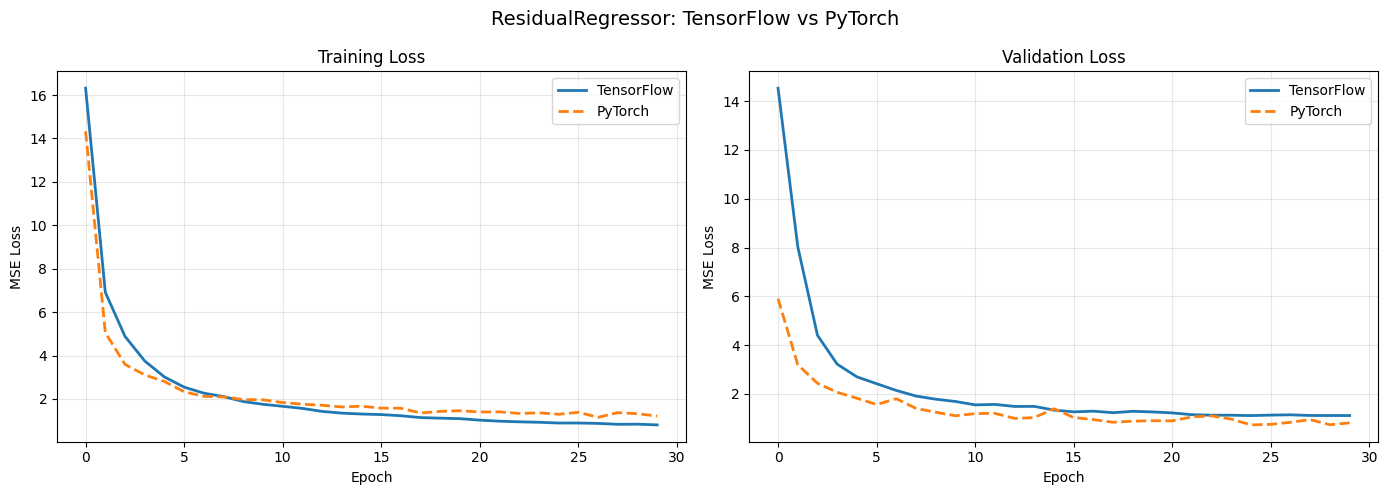

In [13]:
# Compare results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss
axes[0].plot(history_tf.history['loss'], label='TensorFlow', linewidth=2)
axes[0].plot(history_pt['train_loss'], '--', label='PyTorch', linewidth=2)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation loss
axes[1].plot(history_tf.history['val_loss'], label='TensorFlow', linewidth=2)
axes[1].plot(history_pt['val_loss'], '--', label='PyTorch', linewidth=2)
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('ResidualRegressor: TensorFlow vs PyTorch', fontsize=14)
plt.tight_layout()
plt.show()

---

## 4. Multi-Input Models

Models that accept multiple input sources, useful when you have different types of features (e.g., numerical + categorical, image + text).

### 4.1 TensorFlow/Keras Implementation

In [14]:
class MultiInputModel(keras.Model):
    """
    Model with multiple inputs.

    Processes different input types through separate branches,
    then combines them.

    Architecture:
    - Numerical branch: Dense layers
    - Categorical branch: Embedding + Dense
    - Combined: Concatenate + Dense -> Output
    """

    def __init__(self, num_numerical_features, num_categories, embedding_dim=8,
                 hidden_units=[64, 32], output_dim=1, **kwargs):
        super().__init__(**kwargs)

        self.num_numerical_features = num_numerical_features
        self.num_categories = num_categories

        # Numerical branch
        self.numerical_dense1 = layers.Dense(hidden_units[0], activation='relu')
        self.numerical_bn1 = layers.BatchNormalization()
        self.numerical_dense2 = layers.Dense(hidden_units[1], activation='relu')

        # Categorical branch
        self.embedding = layers.Embedding(num_categories, embedding_dim)
        self.cat_flatten = layers.Flatten()
        self.cat_dense = layers.Dense(hidden_units[1], activation='relu')

        # Combined
        self.combined_dense = layers.Dense(hidden_units[1], activation='relu')
        self.dropout = layers.Dropout(0.3)
        self.output_dense = layers.Dense(output_dim)

    def call(self, inputs, training=None):
        """
        Forward pass.

        Parameters:
        -----------
        inputs : dict or tuple
            {'numerical': tensor, 'categorical': tensor} or (numerical, categorical)
        """
        if isinstance(inputs, dict):
            numerical_input = inputs['numerical']
            categorical_input = inputs['categorical']
        else:
            numerical_input, categorical_input = inputs

        # Numerical branch
        num_x = self.numerical_dense1(numerical_input)
        num_x = self.numerical_bn1(num_x, training=training)
        num_x = self.numerical_dense2(num_x)

        # Categorical branch
        cat_x = self.embedding(categorical_input)
        cat_x = self.cat_flatten(cat_x)
        cat_x = self.cat_dense(cat_x)

        # Combine
        combined = layers.concatenate([num_x, cat_x])
        combined = self.combined_dense(combined)
        combined = self.dropout(combined, training=training)

        return self.output_dense(combined)

In [15]:
# Create synthetic multi-input data
np.random.seed(42)
n_samples = 3000

# Numerical features
X_numerical = np.random.randn(n_samples, 10).astype(np.float32)

# Categorical features (indices)
X_categorical = np.random.randint(0, 5, size=(n_samples, 3)).astype(np.int32)

# Target (depends on both)
y = (np.sum(X_numerical[:, :3], axis=1) +
     X_categorical[:, 0] * 0.5 +
     np.random.randn(n_samples) * 0.3).astype(np.float32)

# Split
split = int(0.8 * n_samples)
X_num_train, X_num_test = X_numerical[:split], X_numerical[split:]
X_cat_train, X_cat_test = X_categorical[:split], X_categorical[split:]
y_train_mi, y_test_mi = y[:split], y[split:]

print(f"Numerical features: {X_num_train.shape}")
print(f"Categorical features: {X_cat_train.shape}")
print(f"Target: {y_train_mi.shape}")

Numerical features: (2400, 10)
Categorical features: (2400, 3)
Target: (2400,)


In [16]:
# Train multi-input model
print("Training TensorFlow Multi-Input Model:")
print("=" * 50)

multi_input_model = MultiInputModel(
    num_numerical_features=10,
    num_categories=5,
    embedding_dim=4,
    hidden_units=[64, 32],
    output_dim=1
)

multi_input_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Train with dictionary inputs
history_mi = multi_input_model.fit(
    {'numerical': X_num_train, 'categorical': X_cat_train},
    y_train_mi,
    validation_data=({'numerical': X_num_test, 'categorical': X_cat_test}, y_test_mi),
    epochs=20,
    batch_size=64,
    verbose=1
)

Training TensorFlow Multi-Input Model:
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 3.2804 - mae: 1.4300 - val_loss: 2.7139 - val_mae: 1.3357
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2969 - mae: 0.9040 - val_loss: 1.7850 - val_mae: 1.0823
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7872 - mae: 0.6934 - val_loss: 1.2770 - val_mae: 0.9018
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5511 - mae: 0.5808 - val_loss: 0.9460 - val_mae: 0.7723
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4768 - mae: 0.5314 - val_loss: 0.7141 - val_mae: 0.6686
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4368 - mae: 0.5073 - val_loss: 0.5362 - val_mae: 0.5783
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3872 - mae: 0.4815 - val_loss: 0.4086 - val_mae: 0.5004
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3818 - mae: 0.4756 - val_loss: 0.3320 - val_mae: 0.4518
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━

### 4.2 PyTorch Implementation

In [17]:
class MultiInputModelPyTorch(nn.Module):
    """
    PyTorch Multi-Input Model.
    """

    def __init__(self, num_numerical_features, num_categories, num_cat_features,
                 embedding_dim=8, hidden_units=[64, 32], output_dim=1):
        super().__init__()

        # Numerical branch
        self.num_fc1 = nn.Linear(num_numerical_features, hidden_units[0])
        self.num_bn1 = nn.BatchNorm1d(hidden_units[0])
        self.num_fc2 = nn.Linear(hidden_units[0], hidden_units[1])

        # Categorical branch
        self.embedding = nn.Embedding(num_categories, embedding_dim)
        cat_flat_dim = num_cat_features * embedding_dim
        self.cat_fc = nn.Linear(cat_flat_dim, hidden_units[1])

        # Combined
        self.combined_fc = nn.Linear(hidden_units[1] * 2, hidden_units[1])
        self.dropout = nn.Dropout(0.3)
        self.output_fc = nn.Linear(hidden_units[1], output_dim)

    def forward(self, numerical_input, categorical_input):
        # Numerical branch
        num_x = F.relu(self.num_bn1(self.num_fc1(numerical_input)))
        num_x = F.relu(self.num_fc2(num_x))

        # Categorical branch
        cat_x = self.embedding(categorical_input)
        cat_x = cat_x.view(cat_x.size(0), -1)  # Flatten
        cat_x = F.relu(self.cat_fc(cat_x))

        # Combine
        combined = torch.cat([num_x, cat_x], dim=1)
        combined = F.relu(self.combined_fc(combined))
        combined = self.dropout(combined)

        return self.output_fc(combined)

In [18]:
# Train PyTorch multi-input model
print("Training PyTorch Multi-Input Model:")
print("=" * 50)

# Convert data
X_num_train_pt = torch.tensor(X_num_train)
X_cat_train_pt = torch.tensor(X_cat_train, dtype=torch.long)
y_train_mi_pt = torch.tensor(y_train_mi).unsqueeze(1)

X_num_test_pt = torch.tensor(X_num_test)
X_cat_test_pt = torch.tensor(X_cat_test, dtype=torch.long)
y_test_mi_pt = torch.tensor(y_test_mi).unsqueeze(1)

train_dataset_mi = TensorDataset(X_num_train_pt, X_cat_train_pt, y_train_mi_pt)
train_loader_mi = DataLoader(train_dataset_mi, batch_size=64, shuffle=True)

# Create and train model
multi_input_pt = MultiInputModelPyTorch(
    num_numerical_features=10,
    num_categories=5,
    num_cat_features=3,
    embedding_dim=4,
    hidden_units=[64, 32],
    output_dim=1
)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(multi_input_pt.parameters())

for epoch in range(20):
    multi_input_pt.train()
    for X_num, X_cat, y_batch in train_loader_mi:
        optimizer.zero_grad()
        predictions = multi_input_pt(X_num, X_cat)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 5 == 0:
        multi_input_pt.eval()
        with torch.no_grad():
            val_pred = multi_input_pt(X_num_test_pt, X_cat_test_pt)
            val_loss = criterion(val_pred, y_test_mi_pt).item()
        print(f"Epoch {epoch+1}: Val Loss = {val_loss:.4f}")

Training PyTorch Multi-Input Model:
Epoch 5: Val Loss = 0.1632
Epoch 10: Val Loss = 0.1170
Epoch 15: Val Loss = 0.1089
Epoch 20: Val Loss = 0.1197


---

## 5. Multi-Output Models

Models that produce multiple outputs, useful for multi-task learning.

### 5.1 TensorFlow/Keras Implementation

In [19]:
class MultiOutputModel(keras.Model):
    """
    Multi-task learning model with multiple outputs.

    Architecture:
    Input -> Shared layers -> [Task-specific heads]

    Tasks:
    - Regression output
    - Classification output
    """

    def __init__(self, input_dim, num_classes=3, hidden_units=[128, 64], **kwargs):
        super().__init__(**kwargs)

        # Shared layers
        self.shared_dense1 = layers.Dense(hidden_units[0], activation='relu')
        self.shared_bn1 = layers.BatchNormalization()
        self.shared_dense2 = layers.Dense(hidden_units[1], activation='relu')
        self.shared_bn2 = layers.BatchNormalization()
        self.shared_dropout = layers.Dropout(0.3)

        # Regression head
        self.reg_dense = layers.Dense(32, activation='relu')
        self.reg_output = layers.Dense(1, name='regression_output')

        # Classification head
        self.cls_dense = layers.Dense(32, activation='relu')
        self.cls_output = layers.Dense(num_classes, activation='softmax',
                                       name='classification_output')

    def call(self, inputs, training=None):
        # Shared layers
        x = self.shared_dense1(inputs)
        x = self.shared_bn1(x, training=training)
        x = self.shared_dense2(x)
        x = self.shared_bn2(x, training=training)
        x = self.shared_dropout(x, training=training)

        # Regression head
        reg_x = self.reg_dense(x)
        reg_out = self.reg_output(reg_x)

        # Classification head
        cls_x = self.cls_dense(x)
        cls_out = self.cls_output(cls_x)

        return {'regression_output': reg_out, 'classification_output': cls_out}

In [20]:
# Create synthetic multi-output data
np.random.seed(42)
n_samples = 3000

X_mo = np.random.randn(n_samples, 15).astype(np.float32)

# Regression target
y_reg = np.sum(X_mo[:, :5], axis=1) + np.random.randn(n_samples) * 0.5
y_reg = y_reg.astype(np.float32)

# Classification target (based on regression target)
y_cls = np.digitize(y_reg, bins=[-1, 1]).astype(np.int32)

# Split
split = int(0.8 * n_samples)
X_mo_train, X_mo_test = X_mo[:split], X_mo[split:]
y_reg_train, y_reg_test = y_reg[:split], y_reg[split:]
y_cls_train, y_cls_test = y_cls[:split], y_cls[split:]

print(f"Features shape: {X_mo_train.shape}")
print(f"Regression target shape: {y_reg_train.shape}")
print(f"Classification target shape: {y_cls_train.shape}")
print(f"Class distribution: {np.bincount(y_cls_train)}")

Features shape: (2400, 15)
Regression target shape: (2400,)
Classification target shape: (2400,)
Class distribution: [817 772 811]


In [21]:
# Train multi-output model
print("Training TensorFlow Multi-Output Model:")
print("=" * 50)

multi_output_model = MultiOutputModel(input_dim=15, num_classes=3)

multi_output_model.compile(
    optimizer='adam',
    loss={
        'regression_output': 'mse',
        'classification_output': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'regression_output': 1.0,
        'classification_output': 1.0
    },
    metrics={
        'regression_output': ['mae'],
        'classification_output': ['accuracy']
    }
)

history_mo = multi_output_model.fit(
    X_mo_train,
    {'regression_output': y_reg_train, 'classification_output': y_cls_train},
    validation_data=(
        X_mo_test,
        {'regression_output': y_reg_test, 'classification_output': y_cls_test}
    ),
    epochs=20,
    batch_size=64,
    verbose=1
)

Training TensorFlow Multi-Output Model:
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - classification_output_accuracy: 0.5121 - classification_output_loss: 1.2526 - loss: 3.8317 - regression_output_loss: 2.5635 - regression_output_mae: 1.2440 - val_classification_output_accuracy: 0.6750 - val_classification_output_loss: 0.8947 - val_loss: 4.0934 - val_regression_output_loss: 3.0880 - val_regression_output_mae: 1.3827
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - classification_output_accuracy: 0.6850 - classification_output_loss: 0.6983 - loss: 1.7390 - regression_output_loss: 1.0369 - regression_output_mae: 0.8090 - val_classification_output_accuracy: 0.7483 - val_classification_output_loss: 0.7624 - val_loss: 3.3331 - val_regression_output_loss: 2.4918 - val_regression_output_mae: 1.2390
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - classification_output_accuracy: 0.7471 - classification_output_loss: 0.5523 - loss: 1.3713 - regression_output_loss: 0.8141 - regressio

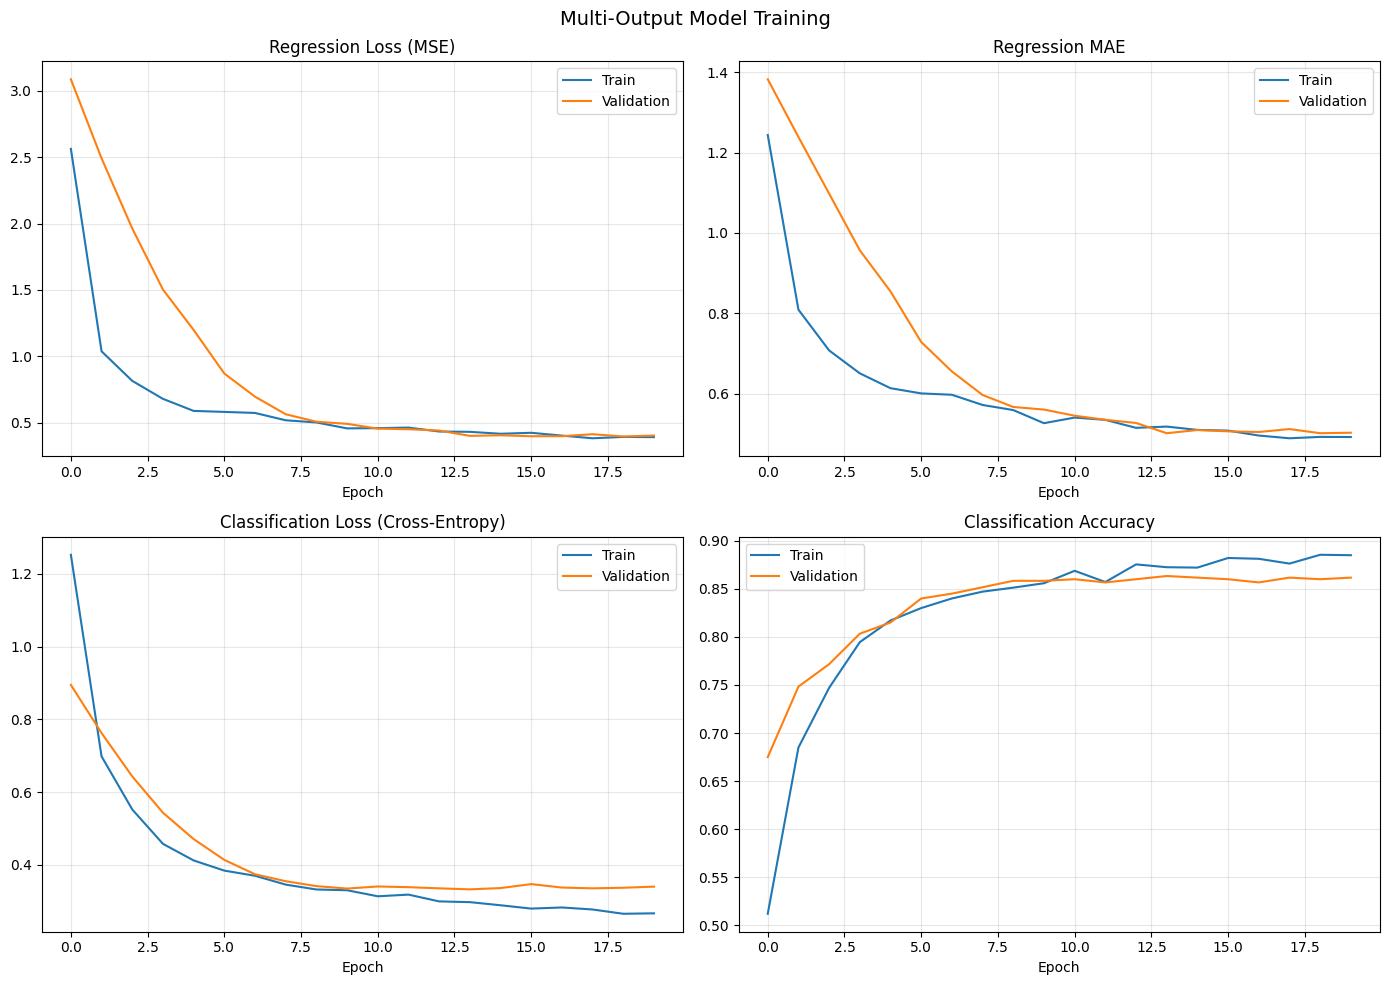

In [22]:
# Visualize multi-output training
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Regression loss
axes[0, 0].plot(history_mo.history['regression_output_loss'], label='Train')
axes[0, 0].plot(history_mo.history['val_regression_output_loss'], label='Validation')
axes[0, 0].set_title('Regression Loss (MSE)')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Regression MAE
axes[0, 1].plot(history_mo.history['regression_output_mae'], label='Train')
axes[0, 1].plot(history_mo.history['val_regression_output_mae'], label='Validation')
axes[0, 1].set_title('Regression MAE')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Classification loss
axes[1, 0].plot(history_mo.history['classification_output_loss'], label='Train')
axes[1, 0].plot(history_mo.history['val_classification_output_loss'], label='Validation')
axes[1, 0].set_title('Classification Loss (Cross-Entropy)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Classification accuracy
axes[1, 1].plot(history_mo.history['classification_output_accuracy'], label='Train')
axes[1, 1].plot(history_mo.history['val_classification_output_accuracy'], label='Validation')
axes[1, 1].set_title('Classification Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Multi-Output Model Training', fontsize=14)
plt.tight_layout()
plt.show()

### 5.2 PyTorch Implementation

In [23]:
class MultiOutputModelPyTorch(nn.Module):
    """
    PyTorch Multi-Output Model.
    """

    def __init__(self, input_dim, num_classes=3, hidden_units=[128, 64]):
        super().__init__()

        # Shared layers
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_units[0]),
            nn.BatchNorm1d(hidden_units[0]),
            nn.ReLU(),
            nn.Linear(hidden_units[0], hidden_units[1]),
            nn.BatchNorm1d(hidden_units[1]),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Regression head
        self.reg_head = nn.Sequential(
            nn.Linear(hidden_units[1], 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

        # Classification head
        self.cls_head = nn.Sequential(
            nn.Linear(hidden_units[1], 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        shared_features = self.shared(x)
        reg_out = self.reg_head(shared_features)
        cls_out = self.cls_head(shared_features)  # No softmax (handled by CrossEntropyLoss)
        return reg_out, cls_out

In [24]:
# Train PyTorch multi-output model
print("Training PyTorch Multi-Output Model:")
print("=" * 50)

# Convert data
X_mo_train_pt = torch.tensor(X_mo_train)
y_reg_train_pt = torch.tensor(y_reg_train).unsqueeze(1)
y_cls_train_pt = torch.tensor(y_cls_train, dtype=torch.long)

X_mo_test_pt = torch.tensor(X_mo_test)
y_reg_test_pt = torch.tensor(y_reg_test).unsqueeze(1)
y_cls_test_pt = torch.tensor(y_cls_test, dtype=torch.long)

train_dataset_mo = TensorDataset(X_mo_train_pt, y_reg_train_pt, y_cls_train_pt)
train_loader_mo = DataLoader(train_dataset_mo, batch_size=64, shuffle=True)

# Create model
multi_output_pt = MultiOutputModelPyTorch(input_dim=15, num_classes=3)

reg_criterion = nn.MSELoss()
cls_criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(multi_output_pt.parameters())

for epoch in range(20):
    multi_output_pt.train()
    total_loss = 0.0

    for X_batch, y_reg_batch, y_cls_batch in train_loader_mo:
        optimizer.zero_grad()

        reg_pred, cls_pred = multi_output_pt(X_batch)

        # Combined loss
        reg_loss = reg_criterion(reg_pred, y_reg_batch)
        cls_loss = cls_criterion(cls_pred, y_cls_batch)
        loss = reg_loss + cls_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        multi_output_pt.eval()
        with torch.no_grad():
            reg_pred, cls_pred = multi_output_pt(X_mo_test_pt)
            val_reg_loss = reg_criterion(reg_pred, y_reg_test_pt).item()
            val_cls_acc = (cls_pred.argmax(dim=1) == y_cls_test_pt).float().mean().item()
        print(f"Epoch {epoch+1}: Reg Loss={val_reg_loss:.4f}, Cls Acc={val_cls_acc:.4f}")

Training PyTorch Multi-Output Model:
Epoch 5: Reg Loss=0.3144, Cls Acc=0.8567
Epoch 10: Reg Loss=0.3180, Cls Acc=0.8650
Epoch 15: Reg Loss=0.3244, Cls Acc=0.8767
Epoch 20: Reg Loss=0.3216, Cls Acc=0.8633


---

## 6. Complex Architecture: Wide & Deep Model

Combines wide (linear) and deep (neural network) components.

In [25]:
class WideAndDeepModel(keras.Model):
    """
    Wide & Deep Model combining memorization and generalization.

    - Wide component: Linear model for memorization
    - Deep component: Deep neural network for generalization
    """

    def __init__(self, wide_dim, deep_dim, hidden_units=[64, 32], output_dim=1, **kwargs):
        super().__init__(**kwargs)

        # Wide component (linear)
        self.wide_dense = layers.Dense(output_dim, name='wide')

        # Deep component
        self.deep_layers = []
        for i, units in enumerate(hidden_units):
            self.deep_layers.append(layers.Dense(units, activation='relu', name=f'deep_{i}'))
            self.deep_layers.append(layers.BatchNormalization(name=f'bn_{i}'))
            self.deep_layers.append(layers.Dropout(0.2, name=f'dropout_{i}'))

        self.deep_output = layers.Dense(output_dim, name='deep_out')

        # Final combination
        self.final_dense = layers.Dense(output_dim, name='output')

    def call(self, inputs, training=None):
        if isinstance(inputs, dict):
            wide_input = inputs['wide']
            deep_input = inputs['deep']
        else:
            wide_input, deep_input = inputs

        # Wide path
        wide_out = self.wide_dense(wide_input)

        # Deep path
        deep_out = deep_input
        for layer in self.deep_layers:
            if isinstance(layer, (layers.BatchNormalization, layers.Dropout)):
                deep_out = layer(deep_out, training=training)
            else:
                deep_out = layer(deep_out)
        deep_out = self.deep_output(deep_out)

        # Combine wide and deep
        combined = layers.concatenate([wide_out, deep_out])
        return self.final_dense(combined)

In [26]:
# Test Wide & Deep model
print("Testing Wide & Deep Model:")
print("=" * 50)

# Create data
np.random.seed(42)
n_samples = 2000

# Wide features (sparse, high-dimensional - e.g., one-hot encoded categories)
X_wide = np.random.randn(n_samples, 100).astype(np.float32)

# Deep features (dense, continuous)
X_deep = np.random.randn(n_samples, 20).astype(np.float32)

# Target
y_wd = (np.sum(X_wide[:, :5], axis=1) * 0.1 +
        np.sum(X_deep[:, :5] ** 2, axis=1) +
        np.random.randn(n_samples) * 0.5).astype(np.float32)

# Split
split = int(0.8 * n_samples)
X_wide_train, X_wide_test = X_wide[:split], X_wide[split:]
X_deep_train, X_deep_test = X_deep[:split], X_deep[split:]
y_wd_train, y_wd_test = y_wd[:split], y_wd[split:]

# Create and train model
wide_deep_model = WideAndDeepModel(
    wide_dim=100,
    deep_dim=20,
    hidden_units=[64, 32],
    output_dim=1
)

wide_deep_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history_wd = wide_deep_model.fit(
    {'wide': X_wide_train, 'deep': X_deep_train},
    y_wd_train,
    validation_data=({'wide': X_wide_test, 'deep': X_deep_test}, y_wd_test),
    epochs=20,
    batch_size=64,
    verbose=1
)

Testing Wide & Deep Model:
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 34.3674 - mae: 4.8760 - val_loss: 32.5310 - val_mae: 4.6714
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 32.1028 - mae: 4.7033 - val_loss: 31.0789 - val_mae: 4.5466
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 29.8726 - mae: 4.5195 - val_loss: 29.3436 - val_mae: 4.3937
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 27.4432 - mae: 4.3200 - val_loss: 27.2266 - val_mae: 4.2063
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24.3946 - mae: 4.0385 - val_loss: 24.5243 - val_mae: 3.9616
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 21.4681 - mae: 3.7652 - val_loss: 21.5947 - val_mae: 3.6890
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 18.0956 - mae: 3.4453 - val_loss: 18.4376 - val_mae: 3.3859
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.8312 - mae: 3.0632 - val_loss: 15.0414 - val_mae: 3.0289
Epoch 9/20
25/25 ━━━━━━━━━━━

---

## 7. Summary and Best Practices

In [27]:
import pandas as pd

# Summary table
summary_data = {
    'Model Type': ['ResidualBlock', 'ResidualRegressor', 'Multi-Input',
                   'Multi-Output', 'Wide & Deep'],
    'Key Feature': ['Skip connections', 'Stacked residual blocks', 'Multiple input branches',
                    'Multiple output heads', 'Wide + Deep paths'],
    'Use Case': ['Deep networks', 'Regression', 'Heterogeneous data',
                 'Multi-task learning', 'Recommender systems'],
    'TensorFlow': ['Layer subclass', 'Model subclass', 'Model subclass',
                   'Model subclass', 'Model subclass'],
    'PyTorch': ['nn.Module', 'nn.Module', 'nn.Module',
                'nn.Module', 'nn.Module']
}

df = pd.DataFrame(summary_data)
print("Custom Models Summary:")
print("=" * 100)
print(df.to_string(index=False))

Custom Models Summary:
       Model Type             Key Feature            Use Case     TensorFlow   PyTorch
    ResidualBlock        Skip connections       Deep networks Layer subclass nn.Module
ResidualRegressor Stacked residual blocks          Regression Model subclass nn.Module
      Multi-Input Multiple input branches  Heterogeneous data Model subclass nn.Module
     Multi-Output   Multiple output heads Multi-task learning Model subclass nn.Module
      Wide & Deep       Wide + Deep paths Recommender systems Model subclass nn.Module


### Best Practices for Custom Models

1. **Architecture Design**
   - Start simple, add complexity as needed
   - Use skip connections for deep networks
   - Consider parameter sharing for efficiency

2. **Training Considerations**
   - Use proper weight initialization
   - Include normalization layers (BatchNorm, LayerNorm)
   - Add dropout for regularization

3. **Multi-Task Learning**
   - Balance loss weights between tasks
   - Consider task relationships when designing shared layers
   - Use gradient clipping if losses have different scales

4. **Debugging**
   - Print intermediate shapes during development
   - Verify gradient flow through skip connections
   - Test with small data first

In [28]:
print("\nNotebook completed successfully!")
print("="*50)
print("Key takeaways:")
print("1. Custom models enable complex architectures beyond sequential")
print("2. ResidualBlocks with skip connections help train deep networks")
print("3. Multi-input models process heterogeneous data types")
print("4. Multi-output models enable multi-task learning")
print("5. Both TensorFlow and PyTorch support flexible model subclassing")


Notebook completed successfully!
Key takeaways:
1. Custom models enable complex architectures beyond sequential
2. ResidualBlocks with skip connections help train deep networks
3. Multi-input models process heterogeneous data types
4. Multi-output models enable multi-task learning
5. Both TensorFlow and PyTorch support flexible model subclassing
